# 06 · Training the full multitask model on synthetic data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE/blob/main/examples/notebooks/06_synthetic_multitask.ipynb)

`HierarchicalKuramotoODE` combines everything from notebooks 01-05: the
biomedical encoder, the Kuramoto+GRAND+attention vector field integrated by
the differentiable RK4 solver, hierarchical attention pooling, and three
task heads — graph classification, node-feature reconstruction, and link
prediction. This notebook trains it on a synthetic dataset (real STEW
training is notebook 07) so the mechanics are visible without needing the
dataset, and closes with an ablation comparison of the Kuramoto and GRAND
switches described in the project README.

In [1]:
# --- Setup -------------------------------------------------------------
# Makes the project importable whether this notebook runs standalone in
# Google Colab or from a local checkout, then imports the shared libraries
# used throughout. Safe to re-run.
import os
import sys
import subprocess

REPO_URL = "https://github.com/D2718281828nis/neuro-GAT-Kuramoto-NeuroODE.git"


def _locate_repo():
    for candidate in (".", "..", "../..", "repo"):
        path = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(path, "hmb_kuramoto_ode")):
            return path
    # A sparse, blobless clone: this repository also bundles a ~490 MB STEW
    # dataset/ folder (see notebook 07), which this notebook does not need.
    subprocess.run(
        ["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
         "--no-checkout", "--sparse", REPO_URL, "repo"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "sparse-checkout", "init", "--cone"], check=True)
    subprocess.run(
        ["git", "-C", "repo", "sparse-checkout", "set", "hmb_kuramoto_ode", "examples", "configs", "pyproject.toml"],
        check=True,
    )
    subprocess.run(["git", "-C", "repo", "checkout", "--quiet"], check=True)
    return os.path.abspath("repo")


REPO_DIR = _locate_repo()
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "torch>=2.5,<3", "numpy>=2,<3", "scipy>=1.14,<2", "scikit-learn>=1.5,<2", "matplotlib>=3.9,<4"],
    check=True,
)

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from hmb_kuramoto_ode.utils.seed import seed_everything

print(f"repository: {REPO_DIR}")
print(f"torch {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


repository: /Users/denmacair/Documents/code_base/neuro-GAT-Kuramoto-NeuroODE
torch 2.13.0 | CUDA available: False


In [2]:
from hmb_kuramoto_ode.data.graph_builder import build_hierarchical_graph, batch_edges
from hmb_kuramoto_ode.models.full_model import HierarchicalKuramotoODE
from hmb_kuramoto_ode.contracts import BANDS
from sklearn.metrics import roc_auc_score

REGIONS = 4
FEATURES = 6
ALPHA_BAND = 2
base_edges, edge_types = build_hierarchical_graph(REGIONS)
nodes_per_graph = REGIONS * 5


def synthetic_dataset(n, seed):
    """Class 1 gets stronger alpha-band power and a phase shift; everything else is noise."""
    g = torch.Generator().manual_seed(seed)
    labels = torch.randint(0, 2, (n,), generator=g)
    x = torch.randn(n, REGIONS, 5, FEATURES, generator=g) * 0.4
    boost = labels.float()[:, None]  # [n, 1], broadcasts against the [n, regions] band slices below
    x[:, :, ALPHA_BAND, 0] += boost * 1.2                      # log power
    x[:, :, ALPHA_BAND, 1] += boost * 0.6                      # relative power
    phase_shift = boost * (torch.pi / 2)
    x[:, :, ALPHA_BAND, 2] = torch.sin(phase_shift)            # overwrite sin(phase)
    x[:, :, ALPHA_BAND, 3] = torch.cos(phase_shift)            # overwrite cos(phase)
    return x, labels


TRAIN_N, VAL_N = 64, 16
xtr, ytr = synthetic_dataset(TRAIN_N, seed=1)
xval, yval = synthetic_dataset(VAL_N, seed=2)
print(f"train {tuple(xtr.shape)}, validation {tuple(xval.shape)}")


train (64, 4, 5, 6), validation (16, 4, 5, 6)


## Link-prediction pairs

For each graph in the batch we sample a handful of real edges (positives)
and random node pairs (negatives, occasionally a real edge by chance — an
acceptable simplification for this toy demo; real STEW training instead
uses the canonical, leakage-checked negative sampling in `data/splits.py`).

In [3]:
def sample_link_pairs(batch_size, nodes_per_graph, base_edges, k_pos=6, k_neg=6, seed=0):
    g = torch.Generator().manual_seed(seed)
    positives, negatives = [], []
    for b in range(batch_size):
        offset = b * nodes_per_graph
        perm = torch.randperm(base_edges.shape[1], generator=g)[:k_pos]
        positives.append(base_edges[:, perm] + offset)
        neg_u = torch.randint(0, nodes_per_graph, (k_neg,), generator=g) + offset
        neg_v = torch.randint(0, nodes_per_graph, (k_neg,), generator=g) + offset
        negatives.append(torch.stack([neg_u, neg_v]))
    pos, neg = torch.cat(positives, dim=1), torch.cat(negatives, dim=1)
    pairs = torch.cat([pos, neg], dim=1)
    targets = torch.cat([torch.ones(pos.shape[1]), torch.zeros(neg.shape[1])])
    return pairs, targets


## Training loop

The combined loss adds graph cross-entropy, node-reconstruction MSE
(reconstructing all nodes here, rather than the masked subset the real
training loop uses, for clarity), and link binary cross-entropy — exactly
the three heads returned by `HierarchicalKuramotoODE.forward`. As in
`examples/stew_real_experiment.py`, the model's edge buffer is swapped
between the train- and validation-sized batches around each evaluation.

In [4]:
train_edges = batch_edges(base_edges, nodes_per_graph, TRAIN_N)
val_edges = batch_edges(base_edges, nodes_per_graph, VAL_N)


def build_model(**ablations):
    seed_everything(0)
    return HierarchicalKuramotoODE(train_edges, features=FEATURES, hidden=16, **ablations)


def train_model(model, epochs=40, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        model.field.edge_index = train_edges
        optimizer.zero_grad()
        pairs, link_targets = sample_link_pairs(TRAIN_N, nodes_per_graph, base_edges, seed=epoch)
        out = model(xtr, edge_pairs=pairs)
        graph_loss = nn.functional.cross_entropy(out["graph_logits"], ytr)
        node_loss = out["node_prediction"].sub(xtr).square().mean()
        link_loss = nn.functional.binary_cross_entropy_with_logits(out["link_logits"], link_targets)
        loss = graph_loss + 0.3 * node_loss + 0.3 * link_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        model.eval()
        model.field.edge_index = val_edges
        with torch.no_grad():
            val_pairs, val_link_targets = sample_link_pairs(VAL_N, nodes_per_graph, base_edges, seed=1000 + epoch)
            val_out = model(xval, edge_pairs=val_pairs)
            val_graph_acc = (val_out["graph_logits"].argmax(1) == yval).float().mean().item()
            val_link_prob = torch.sigmoid(val_out["link_logits"]).numpy()
            val_link_auc = roc_auc_score(val_link_targets.numpy(), val_link_prob)
            val_node_mse = val_out["node_prediction"].sub(xval).square().mean().item()
        history.append(dict(epoch=epoch, loss=loss.item(), graph_loss=graph_loss.item(), node_loss=node_loss.item(),
                             link_loss=link_loss.item(), val_graph_acc=val_graph_acc, val_link_auc=val_link_auc,
                             val_node_mse=val_node_mse))
        model.field.edge_index = train_edges
    return history, model


history, model = train_model(build_model(), epochs=40)
print(f"final validation graph accuracy: {history[-1]['val_graph_acc']:.3f}")
print(f"final validation link AUC:       {history[-1]['val_link_auc']:.3f}")


final validation graph accuracy: 1.000
final validation link AUC:       0.795


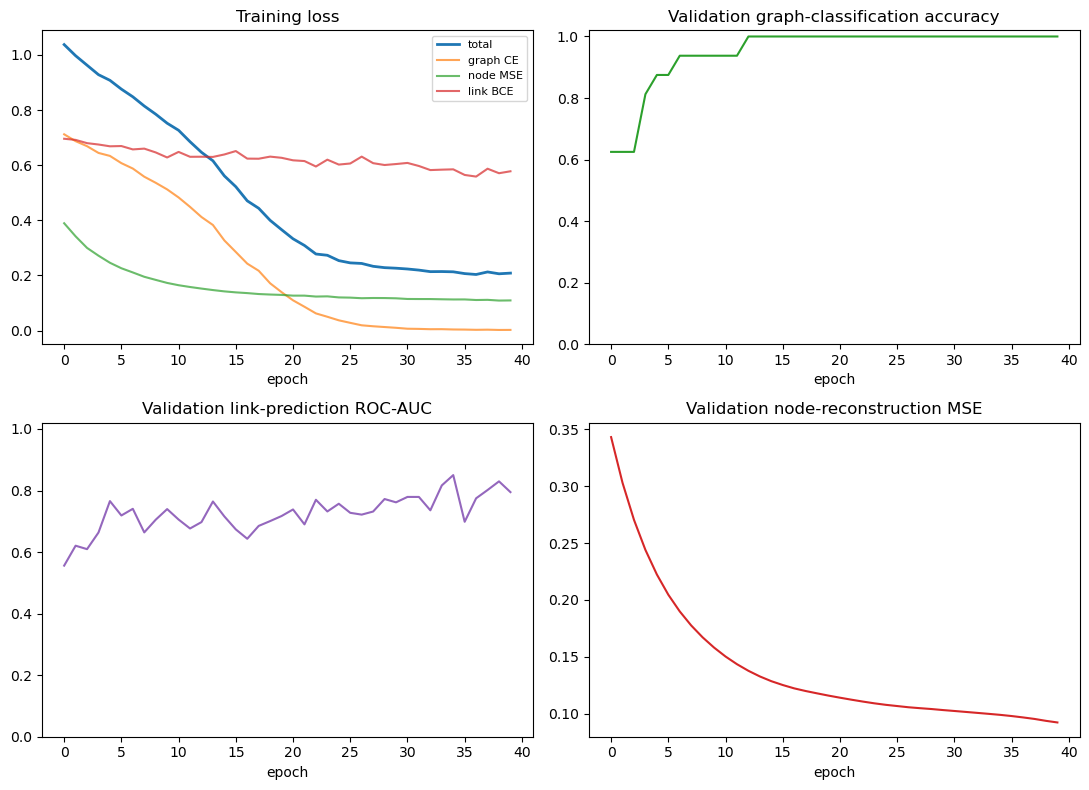

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
epochs = [h["epoch"] for h in history]
axes[0, 0].plot(epochs, [h["loss"] for h in history], label="total", linewidth=2)
axes[0, 0].plot(epochs, [h["graph_loss"] for h in history], label="graph CE", alpha=0.7)
axes[0, 0].plot(epochs, [h["node_loss"] for h in history], label="node MSE", alpha=0.7)
axes[0, 0].plot(epochs, [h["link_loss"] for h in history], label="link BCE", alpha=0.7)
axes[0, 0].set_title("Training loss"); axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(epochs, [h["val_graph_acc"] for h in history], color="tab:green")
axes[0, 1].set_title("Validation graph-classification accuracy"); axes[0, 1].set_ylim(0, 1.02)
axes[1, 0].plot(epochs, [h["val_link_auc"] for h in history], color="tab:purple")
axes[1, 0].set_title("Validation link-prediction ROC-AUC"); axes[1, 0].set_ylim(0, 1.02)
axes[1, 1].plot(epochs, [h["val_node_mse"] for h in history], color="tab:red")
axes[1, 1].set_title("Validation node-reconstruction MSE")
for ax in axes.flat:
    ax.set_xlabel("epoch")
fig.tight_layout()
plt.show()


## What did pooling learn to trust?

The synthetic signal was injected into the alpha band only. `out["attention"]["rhythm"]`
is the hierarchical pooling weight each rhythm receives when it's summarized
into its electrode — a direct, visual check of whether the model learned to
lean on the band that actually carries the label.

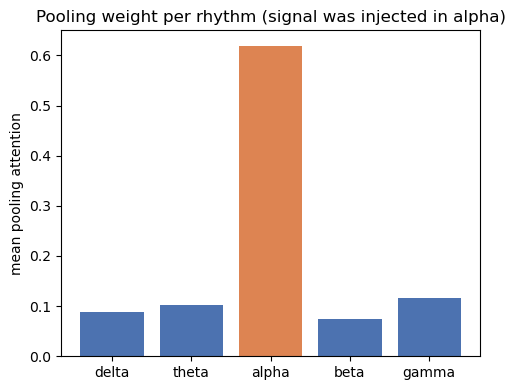

In [6]:
model.eval()
model.field.edge_index = val_edges
with torch.no_grad():
    val_pairs, _ = sample_link_pairs(VAL_N, nodes_per_graph, base_edges, seed=99)
    out = model(xval, edge_pairs=val_pairs)

rhythm_attention = out["attention"]["rhythm"].mean(dim=(0, 1)).detach().numpy()  # mean over batch & electrode -> [5]
fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#DD8452" if band == BANDS[ALPHA_BAND] else "#4C72B0" for band in BANDS]
ax.bar(BANDS, rhythm_attention, color=colors)
ax.set_ylabel("mean pooling attention")
ax.set_title(f"Pooling weight per rhythm (signal was injected in {BANDS[ALPHA_BAND]})")
fig.tight_layout()
plt.show()


## Ablating Kuramoto and GRAND

`HierarchicalKuramotoODE` accepts the same ablation switches as the CLI
(`kuramoto=False`, `grand=False`, `cross_frequency=False`, `residual=False`).
Below, four short training runs compare the full model against disabling
each coupling mechanism, holding everything else fixed. On a task this
small, every variant eventually reaches similar *final* accuracy — the
encoder and pooling head alone can already fit it — so the more honest
comparison is the *learning curve*: how quickly each variant gets there,
which is where the coupling mechanisms actually earn their keep.

full (Kuramoto+GRAND): validation accuracy after 15 epochs = 1.000


Kuramoto-only: validation accuracy after 15 epochs = 1.000


GRAND-only: validation accuracy after 15 epochs = 1.000


neither (residual only): validation accuracy after 15 epochs = 1.000


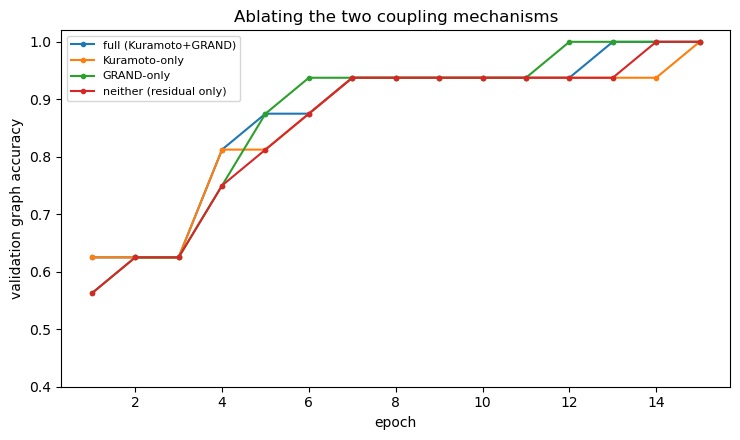

In [7]:
ablation_settings = {
    "full (Kuramoto+GRAND)": {},
    "Kuramoto-only": {"grand": False},
    "GRAND-only": {"kuramoto": False},
    "neither (residual only)": {"grand": False, "kuramoto": False},
}
ablation_curves = {}
for name, ablation in ablation_settings.items():
    ablation_history, _ = train_model(build_model(**ablation), epochs=15)
    ablation_curves[name] = [h["val_graph_acc"] for h in ablation_history]
    print(f"{name}: validation accuracy after 15 epochs = {ablation_curves[name][-1]:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, curve in ablation_curves.items():
    ax.plot(range(1, len(curve) + 1), curve, marker="o", markersize=3, label=name)
ax.set(xlabel="epoch", ylabel="validation graph accuracy", title="Ablating the two coupling mechanisms")
ax.set_ylim(0.4, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Key takeaway

This is a small, synthetic, single-seed comparison — not a claim about
which mechanism matters more on real EEG (see notebook 07 and the README's
"no superiority claimed" note), and the curves above can reorder with a
different seed or a slightly larger/smaller signal. What it does show
concretely is that the ablation switches actually change the model's
learning dynamics, and that the combined loss, the pooling attention, and
the link/node/graph heads all train together through one shared ODE
integration, as described in the project README's "How the code works"
section.